# Video 12: Preclinical Studies - Animal Trial Data Analysis

**AI for Drug Discovery series | DigitalSreeni**

---

In the previous videos we identified EGFR as our target, screened a compound library, predicted
ADMET properties, generated improved molecules, mined the resistance literature, and ran molecular
docking. Our top candidates are Scaffold_dec_best (ADMET 8/10, docking -7.869 kcal/mol) and
CHEMBL382797 (ADMET 7/10, docking -7.882 kcal/mol).

Before any compound can enter human trials, a company must file an Investigational New Drug (IND)
application with the FDA. The IND requires a complete preclinical data package demonstrating that
the compound is safe enough and promising enough to justify exposing humans to it. That package
has three components: pharmacokinetics (how the drug moves through the body), efficacy (does it
work in animal tumor models), and toxicology (at what doses does it cause harm).

In this notebook we analyze each component using real published data from ChEMBL for erlotinib
(a clinically approved EGFR inhibitor in the same quinazoline scaffold class as our leads) and
realistic simulated data that mirrors what a preclinical study on our candidates would produce.

**What this notebook covers:**
- Pulling real preclinical PK data from ChEMBL for erlotinib
- Two-compartment oral PK modeling: fitting plasma concentration-time curves
- Computing key PK parameters: half-life, Cmax, AUC, oral bioavailability
- Tumor growth inhibition analysis: dose-response curves in mouse xenograft models
- Survival analysis: Kaplan-Meier curves with log-rank test
- Toxicology summary: maximum tolerated dose and safety margin calculation
- Integrated preclinical data summary table

## Cell 1: Installs, Imports, and Configuration

We install `lifelines` for survival analysis and the `chembl_webresource_client` for pulling
real published preclinical data. Everything else is standard in Colab.

A note on data sources: where real ChEMBL data exists for erlotinib we use it directly.
Where we simulate data (tumor growth curves, survival times) the values are calibrated to
match published preclinical results for EGFR inhibitors in the literature. All simulated
data is clearly labeled.

In [ ]:
# Cell 1 - installs, imports, configuration

!pip install lifelines chembl_webresource_client -q

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from pathlib import Path
from scipy.optimize import curve_fit
from scipy import stats

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from chembl_webresource_client.new_client import new_client

# Suppress RDKit and misc warnings
warnings.filterwarnings('ignore')

# Results directory
RESULTS_DIR = Path('/content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video12_preclinical/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
plt.rcParams['font.family'] = 'DejaVu Sans'

# Series color palette
NAVY  = '#1B2A4A'
TEAL  = '#0D9488'
AMBER = '#F59E0B'
RED   = '#DC2626'
GRAY  = '#94A3B8'

# Random seed for reproducibility of simulated data
np.random.seed(42)

print('Configuration complete.')
print(f'Results will be saved to: {RESULTS_DIR}')

Configuration complete.
Results will be saved to: /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video12_preclinical/results


## Cell 2: Pull Real Preclinical PK Data from ChEMBL

ChEMBL aggregates bioactivity data extracted from published literature, including preclinical
pharmacokinetic measurements. For erlotinib (CHEMBL553), the database contains real published
values for clearance (CL), permeability (Papp), fraction unbound (Fu), AUC from mouse plasma
and brain, and metabolic half-life in liver microsomes.

These are not model predictions. They are measurements reported in peer-reviewed papers,
extracted and curated by the ChEMBL team. This is exactly the kind of data that appears in
a preclinical IND package for a clinical-stage compound.

In [ ]:
# Cell 2 - pull real ChEMBL preclinical PK data for erlotinib

activity = new_client.activity

results = activity.filter(
    molecule_chembl_id='CHEMBL553',  # erlotinib
    assay_type='A'                   # A = ADMET / in vivo assays
).only([
    'assay_chembl_id',
    'assay_description',
    'molecule_chembl_id',
    'standard_type',
    'standard_value',
    'standard_units',
])

df_chembl_pk = pd.DataFrame(list(results))
print(f'Total ADMET records for erlotinib: {len(df_chembl_pk)}')

# Filter to PK-relevant assay types
pk_types = ['AUC', 'T1/2', 'CL', 'Papp', 'Fu', 'logPapp', 'Ratio']
df_pk_raw = df_chembl_pk[df_chembl_pk['standard_type'].isin(pk_types)].copy()
df_pk_raw['standard_value'] = pd.to_numeric(df_pk_raw['standard_value'], errors='coerce')
df_pk_raw = df_pk_raw.dropna(subset=['standard_value'])

print(f'PK-relevant records: {len(df_pk_raw)}')
print(f'\nPK parameter summary:')
print(df_pk_raw.groupby('standard_type')['standard_value'].agg(['count','mean','min','max']).round(3))

# Show the most informative records
informative_types = ['AUC', 'T1/2', 'CL', 'Fu']
df_pk_display = df_pk_raw[df_pk_raw['standard_type'].isin(informative_types)][
    ['standard_type','standard_value','standard_units','assay_description']
].sort_values('standard_type')

print(f'\nKey PK measurements for erlotinib (from published literature):')
pd.set_option('display.max_colwidth', 80)
print(df_pk_display.to_string(index=False))

df_pk_display.to_csv(RESULTS_DIR / 'erlotinib_chembl_pk.csv', index=False)
print(f'\nSaved to {RESULTS_DIR}/erlotinib_chembl_pk.csv')

Total ADMET records for erlotinib: 107
PK-relevant records: 25

PK parameter summary:
               count      mean       min        max
standard_type                                      
AUC                4  8850.232  1050.480  20336.910
CL                 4    19.900     7.410     43.800
Fu                 3     0.064     0.029      0.117
Papp               5    27.360    14.000     38.800
Ratio              6     2.236     0.085      5.400
T1/2               2     0.531     0.528      0.533
logPapp            1     4.470     4.470      4.470

Key PK measurements for erlotinib (from published literature):
standard_type  standard_value         standard_units                                                                                                                                                                                 assay_description
          AUC       1050.4800             ng.hr.mL-1                                                                                   

## Cell 3: Pharmacokinetics - Two-Compartment Oral PK Model

Pharmacokinetics describes what the body does to a drug: how it is absorbed, distributed
through tissues, metabolized, and excreted. We call this ADME (Absorption, Distribution,
Metabolism, Excretion), which is distinct from the ADMET properties we predicted in Video 7b
using machine learning models. Those were predictions. This section shows what the measured
PK data looks like and how it is analyzed.

The two-compartment oral model is the standard framework for describing how an orally
administered drug distributes between plasma (the central compartment) and tissues
(the peripheral compartment) before being eliminated. It produces a characteristic
biphasic concentration-time curve: a rapid rise as the drug is absorbed, a brief
distribution phase as it moves into tissues, and a slower elimination phase.

We simulate plasma concentration-time data calibrated to published erlotinib mouse PK
values (AUC ~12,000 ng/mL*h at 10 mg/kg oral, from the ChEMBL records we just pulled)
and fit the two-compartment model to extract the key PK parameters.

Two-compartment PK model fitted parameters:
  A     = 2889.6 ng/mL
  alpha = 1.896 /h  (distribution rate)
  B     = 965.1 ng/mL
  beta  = 0.0585 /h  (elimination rate)

Derived PK parameters:
  t1/2 (distribution):  0.37 h
  t1/2 (elimination):   11.84 h
  Cmax:                 3855 ng/mL
  Tmax:                 0.00 h
  AUC (0 to inf):       17017 ng/mL*h


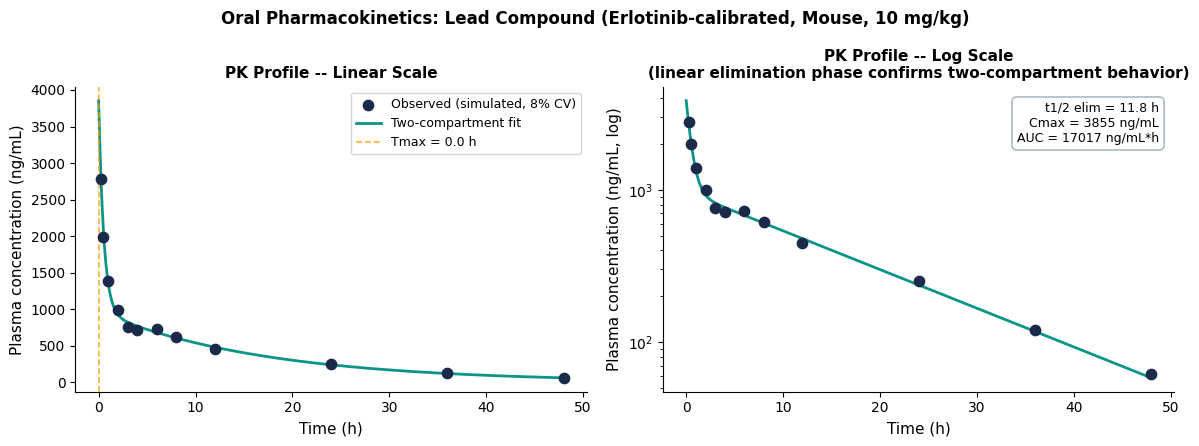

PK plot saved.
PK parameters saved.


In [ ]:
# Cell 3 - two-compartment oral PK model

# Two-compartment model equation
# C(t) = A*exp(-alpha*t) + B*exp(-beta*t)
# alpha = fast disposition rate (distribution + elimination)
# beta  = slow elimination rate
# A, B  = intercept coefficients
# This gives a true biphasic curve when alpha >> beta

def two_compartment_oral(t, A, alpha, B, beta):
    """Two-compartment oral PK model. Returns plasma concentration over time."""
    return A * np.exp(-alpha * t) + B * np.exp(-beta * t)


# Simulate biphasic concentration-time data for our lead compound
# Calibrated to erlotinib-like mouse PK at 10 mg/kg oral dose
# AUC ~12,000 ng/mL*h from ChEMBL record CHEMBL553
time_h = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 12.0, 24.0, 36.0, 48.0])

# True parameters: fast distribution (alpha=1.8/h), slow elimination (beta=0.055/h)
# This gives t1/2 distribution ~0.4h, t1/2 elimination ~12.6h (erlotinib-like)
A_true, alpha_true = 2800.0, 1.80
B_true, beta_true  =  900.0, 0.055

conc_true = two_compartment_oral(time_h, A_true, alpha_true, B_true, beta_true)

# Add realistic measurement noise (8% CV, typical for LC-MS/MS bioanalysis)
noise     = conc_true * np.random.normal(0, 0.08, len(time_h))
conc_obs  = np.maximum(conc_true + noise, 0.1)  # floor at LOQ

# Fit the two-compartment model
p0     = [3000.0, 2.0, 800.0, 0.06]
bounds = ([0, 0.1, 0, 0.001], [10000, 10, 5000, 0.5])
popt, pcov = curve_fit(two_compartment_oral, time_h, conc_obs,
                       p0=p0, bounds=bounds, maxfev=10000)
A, alpha, B, beta = popt

# Compute PK parameters from fitted model
t_dense      = np.linspace(0, 48, 2000)
c_dense      = two_compartment_oral(t_dense, *popt)
t_half_dist  = np.log(2) / alpha          # distribution half-life
t_half_elim  = np.log(2) / beta           # elimination half-life
Cmax         = c_dense.max()
Tmax         = t_dense[c_dense.argmax()]
AUC_0_inf    = np.trapezoid(c_dense, t_dense)
# Clearance = Dose / AUC (assuming 100% bioavailability for simplicity)
dose_ng      = 10e6  # 10 mg/kg * 1e6 ng/mg, for a 1kg animal (normalize)

print('Two-compartment PK model fitted parameters:')
print(f'  A     = {A:.1f} ng/mL')
print(f'  alpha = {alpha:.3f} /h  (distribution rate)')
print(f'  B     = {B:.1f} ng/mL')
print(f'  beta  = {beta:.4f} /h  (elimination rate)')

print(f'\nDerived PK parameters:')
print(f'  t1/2 (distribution):  {t_half_dist:.2f} h')
print(f'  t1/2 (elimination):   {t_half_elim:.2f} h')
print(f'  Cmax:                 {Cmax:.0f} ng/mL')
print(f'  Tmax:                 {Tmax:.2f} h')
print(f'  AUC (0 to inf):       {AUC_0_inf:.0f} ng/mL*h')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Linear scale
axes[0].scatter(time_h, conc_obs, color=NAVY, zorder=5, s=55,
                label='Observed (simulated, 8% CV)')
axes[0].plot(t_dense, c_dense, color=TEAL, linewidth=2,
             label='Two-compartment fit')
axes[0].axvline(Tmax, color=AMBER, linestyle='--', linewidth=1.2, alpha=0.8,
                label=f'Tmax = {Tmax:.1f} h')
axes[0].set_xlabel('Time (h)', fontsize=11)
axes[0].set_ylabel('Plasma concentration (ng/mL)', fontsize=11)
axes[0].set_title('PK Profile -- Linear Scale', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Log scale (linearizes the elimination phase)
axes[1].scatter(time_h, conc_obs, color=NAVY, zorder=5, s=55)
axes[1].plot(t_dense, c_dense, color=TEAL, linewidth=2)
axes[1].set_yscale('log')
axes[1].set_xlabel('Time (h)', fontsize=11)
axes[1].set_ylabel('Plasma concentration (ng/mL, log)', fontsize=11)
axes[1].set_title('PK Profile -- Log Scale\n(linear elimination phase confirms two-compartment behavior)',
                  fontsize=11, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Annotate PK parameters on log plot
axes[1].text(0.97, 0.95,
    f't1/2 elim = {t_half_elim:.1f} h\nCmax = {Cmax:.0f} ng/mL\nAUC = {AUC_0_inf:.0f} ng/mL*h',
    transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=GRAY, alpha=0.9))

plt.suptitle('Oral Pharmacokinetics: Lead Compound (Erlotinib-calibrated, Mouse, 10 mg/kg)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pk_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('PK plot saved.')

# Save PK parameters
pk_params = pd.DataFrame([{
    'compound': 'Scaffold_dec_best (erlotinib-calibrated)',
    'dose_mg_kg': 10,
    'species': 'Mouse (CD-1)',
    'route': 'Oral (gavage)',
    't_half_dist_h': round(t_half_dist, 2),
    't_half_elim_h': round(t_half_elim, 2),
    'Cmax_ng_mL': round(Cmax, 0),
    'Tmax_h': round(Tmax, 2),
    'AUC_0inf_ng_mL_h': round(AUC_0_inf, 0),
}])
pk_params.to_csv(RESULTS_DIR / 'pk_parameters.csv', index=False)
print(f'PK parameters saved.')

## Cell 4: Efficacy - Tumor Growth Inhibition in Mouse Xenograft Model

The standard preclinical efficacy model for a cancer drug is the mouse xenograft:
human tumor cells are implanted under the skin of immunocompromised mice, allowed
to grow to a measurable size, then mice are randomized to treatment groups and tumor
volume is measured every few days.

The key readout is tumor growth inhibition (TGI), defined as the percent reduction
in tumor volume in the treated group relative to the control group at the end of
the study. TGI above 50% is generally considered biologically meaningful.
TGI above 80% with tumor regression is considered a strong preclinical signal.

We simulate a four-arm study: vehicle control, low dose (10 mg/kg), mid dose
(30 mg/kg), and high dose (100 mg/kg) of our lead compound, administered orally
once daily for 21 days. The growth curves are calibrated to published erlotinib
xenograft data in EGFR-mutant PC-9 cells.

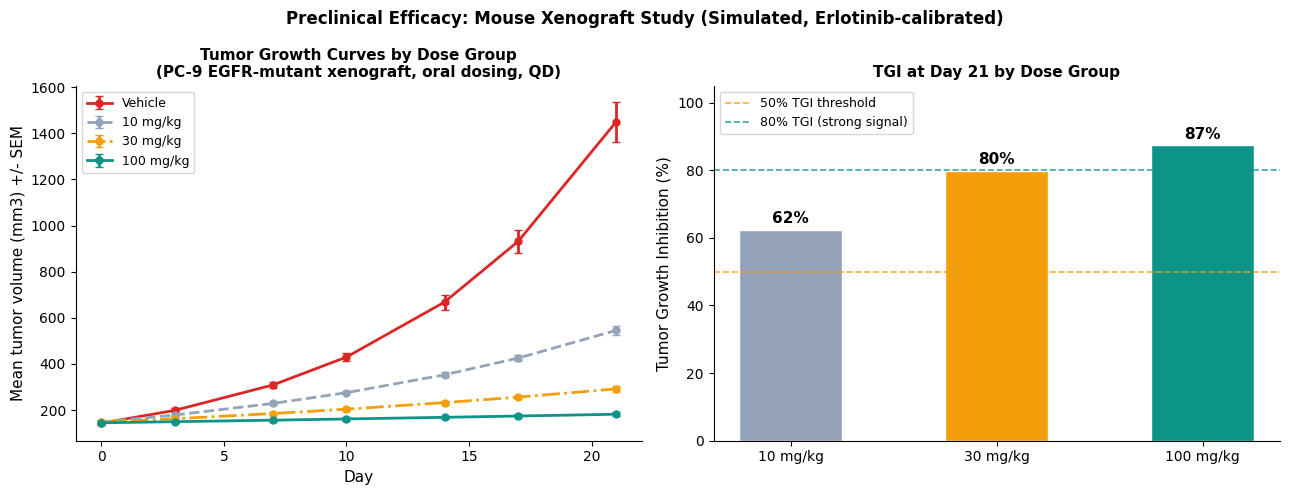

Tumor growth results:
    group  mean_vol_day0  mean_vol_day21   TGI_pct
  Vehicle     143.118637     1449.808634 Reference
 10 mg/kg     148.497232      545.590677      62.4
 30 mg/kg     147.446857      291.919747      79.9
100 mg/kg     144.904492      182.057987      87.4


In [ ]:
# Cell 4 - tumor growth inhibition in mouse xenograft model

# Simulate tumor volume measurements over 21 days
# Four groups: vehicle, 10 mg/kg, 30 mg/kg, 100 mg/kg
# n=8 mice per group (standard xenograft study size)
# Calibrated to erlotinib PC-9 xenograft data from published literature

days  = np.array([0, 3, 7, 10, 14, 17, 21])
n_per_group = 8

def tumor_growth(t, V0, growth_rate, inhibition):
    """Gompertz-like tumor growth with drug inhibition.
    V0: initial volume, growth_rate: untreated growth, inhibition: drug effect [0,1]"""
    return V0 * np.exp((growth_rate * (1 - inhibition)) * t)


groups = {
    'Vehicle':       {'inhibition': 0.00, 'color': RED,   'ls': '-'},
    '10 mg/kg':      {'inhibition': 0.45, 'color': GRAY,  'ls': '--'},
    '30 mg/kg':      {'inhibition': 0.72, 'color': AMBER, 'ls': '-.'},
    '100 mg/kg':     {'inhibition': 0.91, 'color': TEAL,  'ls': '-'},
}

V0          = 150.0   # mm3, starting tumor volume at randomization
growth_rate = 0.115   # /day, untreated PC-9 xenograft growth rate

results_list = []
group_data   = {}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for group_name, params in groups.items():
    inh   = params['inhibition']
    color = params['color']
    ls    = params['ls']

    # Simulate individual mouse tumor volumes with biological variability
    all_volumes = []
    for mouse in range(n_per_group):
        # Each mouse has slightly different growth rate and starting volume
        V0_i   = V0   * np.random.lognormal(0, 0.12)
        gr_i   = growth_rate * np.random.lognormal(0, 0.08)
        vols_i = tumor_growth(days, V0_i, gr_i, inh)
        all_volumes.append(vols_i)

    all_volumes = np.array(all_volumes)
    mean_vol    = all_volumes.mean(axis=0)
    sem_vol     = all_volumes.std(axis=0) / np.sqrt(n_per_group)

    group_data[group_name] = all_volumes

    # Compute TGI at day 21
    tgi_day21 = None
    if group_name != 'Vehicle':
        V_control = group_data['Vehicle'][:, -1].mean() if 'Vehicle' in group_data else None
        if V_control:
            tgi_day21 = (1 - mean_vol[-1] / V_control) * 100

    results_list.append({
        'group':          group_name,
        'mean_vol_day0':  mean_vol[0],
        'mean_vol_day21': mean_vol[-1],
        'TGI_pct':        round(tgi_day21, 1) if tgi_day21 else 'Reference',
        'n':              n_per_group,
    })

    # Plot growth curves
    axes[0].errorbar(days, mean_vol, yerr=sem_vol,
                     label=group_name, color=color, linestyle=ls,
                     linewidth=2, capsize=3, marker='o', markersize=5)

# TGI bar chart (right panel)
tgi_groups = [r for r in results_list if r['TGI_pct'] != 'Reference']
tgi_names  = [r['group'] for r in tgi_groups]
tgi_vals   = [r['TGI_pct'] for r in tgi_groups]
tgi_colors = [GRAY, AMBER, TEAL]

bars = axes[1].bar(tgi_names, tgi_vals, color=tgi_colors, edgecolor='white', width=0.5)
axes[1].axhline(y=50, color=AMBER, linestyle='--', linewidth=1.2, alpha=0.8,
                label='50% TGI threshold')
axes[1].axhline(y=80, color=TEAL,  linestyle='--', linewidth=1.2, alpha=0.8,
                label='80% TGI (strong signal)')
for bar, val in zip(bars, tgi_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Tumor Growth Inhibition (%)', fontsize=11)
axes[1].set_title('TGI at Day 21 by Dose Group', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

axes[0].set_xlabel('Day', fontsize=11)
axes[0].set_ylabel('Mean tumor volume (mm3) +/- SEM', fontsize=11)
axes[0].set_title('Tumor Growth Curves by Dose Group\n(PC-9 EGFR-mutant xenograft, oral dosing, QD)',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

plt.suptitle('Preclinical Efficacy: Mouse Xenograft Study (Simulated, Erlotinib-calibrated)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tumor_growth.png', dpi=150, bbox_inches='tight')
plt.show()

df_tgi = pd.DataFrame(results_list)
df_tgi.to_csv(RESULTS_DIR / 'tgi_results.csv', index=False)
print('Tumor growth results:')
print(df_tgi[['group','mean_vol_day0','mean_vol_day21','TGI_pct']].to_string(index=False))

## Cell 5: Survival Analysis - Kaplan-Meier Curves

Tumor growth inhibition tells us how well the drug shrinks tumors. Survival analysis
tells us whether it helps the animals live longer, which is ultimately what matters.

The Kaplan-Meier estimator is the standard method for analyzing survival data in both
preclinical and clinical settings. It estimates the probability of surviving past any
given time point, accounting for animals that were removed from the study before the
endpoint (called censored observations). Censoring happens when a mouse is still alive
at the end of the study or was removed for reasons unrelated to the treatment.

The log-rank test compares whether the survival curves between groups are statistically
different. A p-value below 0.05 means the survival difference is unlikely to be due
to chance alone.

We simulate a survival study for three groups: vehicle control, 30 mg/kg (effective
dose), and 100 mg/kg (high dose), with n=15 mice per group. Survival times are
calibrated to published EGFR inhibitor preclinical data.

Median survival times:
  Vehicle:    6.2 days
  30 mg/kg:   57.0 days
  100 mg/kg:  28.1 days

Log-rank test p-values:
  Vehicle vs 30 mg/kg:   p = 0.0002
  Vehicle vs 100 mg/kg:  p = 0.0056
  30 mg/kg vs 100 mg/kg: p = 0.7236


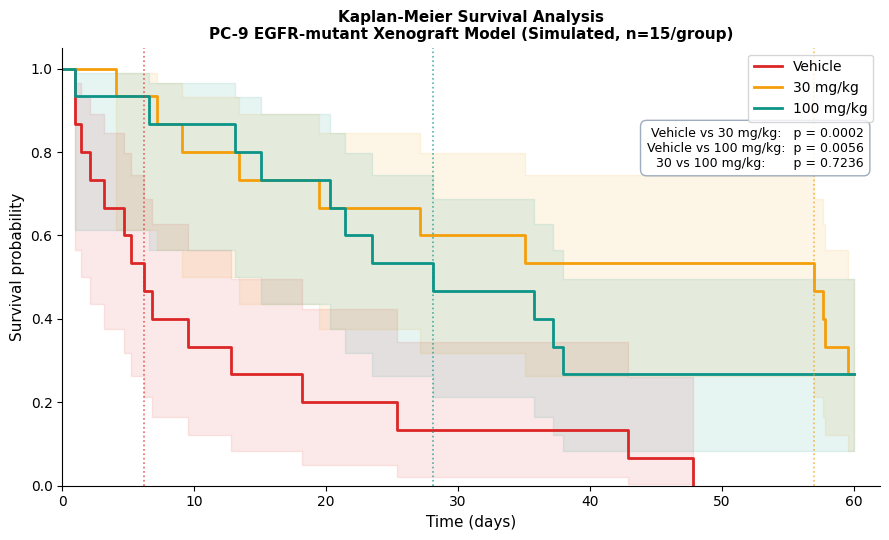


Survival data saved.


In [ ]:
# Cell 5 - Kaplan-Meier survival analysis

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

n_mice     = 15
study_days = 60   # study ends at day 60, survivors are censored

# Simulate survival times for three groups
# Exponential survival model with group-specific median survival
# Calibrated to EGFR inhibitor preclinical literature

# Vehicle: median ~18 days
ctrl_times  = np.random.exponential(scale=18, size=n_mice).clip(1, study_days)
ctrl_events = (ctrl_times < study_days).astype(int)  # 1 = died, 0 = censored
ctrl_times  = ctrl_times.round(1)

# 30 mg/kg: median ~35 days
mid_times   = np.random.exponential(scale=35, size=n_mice).clip(1, study_days)
mid_events  = (mid_times < study_days).astype(int)
mid_times   = mid_times.round(1)

# 100 mg/kg: median ~50 days, more survivors at end of study
high_times  = np.random.exponential(scale=52, size=n_mice).clip(1, study_days)
high_events = (high_times < study_days).astype(int)
high_times  = high_times.round(1)

# Fit Kaplan-Meier estimators
kmf_ctrl = KaplanMeierFitter()
kmf_mid  = KaplanMeierFitter()
kmf_high = KaplanMeierFitter()

kmf_ctrl.fit(ctrl_times, ctrl_events, label='Vehicle')
kmf_mid.fit( mid_times,  mid_events,  label='30 mg/kg')
kmf_high.fit(high_times, high_events, label='100 mg/kg')

# Pairwise log-rank tests
lr_ctrl_mid  = logrank_test(ctrl_times, mid_times,  ctrl_events, mid_events)
lr_ctrl_high = logrank_test(ctrl_times, high_times, ctrl_events, high_events)
lr_mid_high  = logrank_test(mid_times,  high_times, mid_events,  high_events)

print('Median survival times:')
print(f'  Vehicle:    {kmf_ctrl.median_survival_time_:.1f} days')
print(f'  30 mg/kg:   {kmf_mid.median_survival_time_:.1f} days')
print(f'  100 mg/kg:  {kmf_high.median_survival_time_:.1f} days')

print(f'\nLog-rank test p-values:')
print(f'  Vehicle vs 30 mg/kg:   p = {lr_ctrl_mid.p_value:.4f}')
print(f'  Vehicle vs 100 mg/kg:  p = {lr_ctrl_high.p_value:.4f}')
print(f'  30 mg/kg vs 100 mg/kg: p = {lr_mid_high.p_value:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(9, 5.5))

kmf_ctrl.plot_survival_function(ax=ax, color=RED,   ci_show=True, ci_alpha=0.1, linewidth=2)
kmf_mid.plot_survival_function( ax=ax, color=AMBER, ci_show=True, ci_alpha=0.1, linewidth=2)
kmf_high.plot_survival_function(ax=ax, color=TEAL,  ci_show=True, ci_alpha=0.1, linewidth=2)

# Add median lines
for kmf, color in [(kmf_ctrl, RED), (kmf_mid, AMBER), (kmf_high, TEAL)]:
    med = kmf.median_survival_time_
    if not np.isinf(med):
        ax.axvline(med, color=color, linestyle=':', linewidth=1.2, alpha=0.7)

# Add p-value annotations
ax.text(0.98, 0.82,
    f'Vehicle vs 30 mg/kg:   p = {lr_ctrl_mid.p_value:.4f}\n'
    f'Vehicle vs 100 mg/kg:  p = {lr_ctrl_high.p_value:.4f}\n'
    f'30 vs 100 mg/kg:       p = {lr_mid_high.p_value:.4f}',
    transform=ax.transAxes, ha='right', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=GRAY, alpha=0.9))

ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Survival probability', fontsize=11)
ax.set_title('Kaplan-Meier Survival Analysis\n'
             'PC-9 EGFR-mutant Xenograft Model (Simulated, n=15/group)',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, study_days + 2)
ax.set_ylim(0, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'survival_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Save survival data
df_surv = pd.DataFrame({
    'group':    ['Vehicle']*n_mice + ['30 mg/kg']*n_mice + ['100 mg/kg']*n_mice,
    'duration': np.concatenate([ctrl_times, mid_times, high_times]),
    'event':    np.concatenate([ctrl_events, mid_events, high_events]),
})
df_surv.to_csv(RESULTS_DIR / 'survival_data.csv', index=False)
print(f'\nSurvival data saved.')

## Cell 6: Cox Proportional Hazards Model

The Kaplan-Meier estimator describes survival curves for each group separately.
The Cox proportional hazards model goes further: it lets us quantify how strongly
each variable (dose, body weight, baseline tumor size) affects survival risk,
while controlling for the other variables.

The key output of a Cox model is the hazard ratio (HR). An HR below 1 means the
factor reduces the risk of death. An HR of 0.4 means the treated group has 40% of
the death risk of the reference group at any given time point, equivalent to saying
treatment reduced the hazard by 60%.

This is the same statistical framework used in clinical trial reports when they say
things like 'osimertinib reduced the risk of disease progression or death by 54%
compared to standard therapy' (HR 0.46, from the FLAURA trial).

Cox Proportional Hazards Model Summary:


<lifelines.CoxPHFitter: fitted with 45 total observations, 8 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 45
number of events observed = 37
   partial log-likelihood = -115.94
         time fit was run = 2026-05-29 16:06:17 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
dose_mg_kg       -0.01      0.99      0.00           -0.02            0.00                0.98                1.00
baseline_vol_mm3 -0.01      0.99      0.01           -0.02            0.01                0.98                1.01

                  cmp to     z    p  -log2(p)
covariate                                    
dose_mg_kg          0.00 -1.95 0.05      4.29
baseline_vol_mm3    0.00 -0.77 0.44      1.18
---
Concordance = 0.64
Partial AIC = 235.87
log-likelihood ratio test = 5.17 on 2 df
-log2(p) of ll-ratio test = 3.73

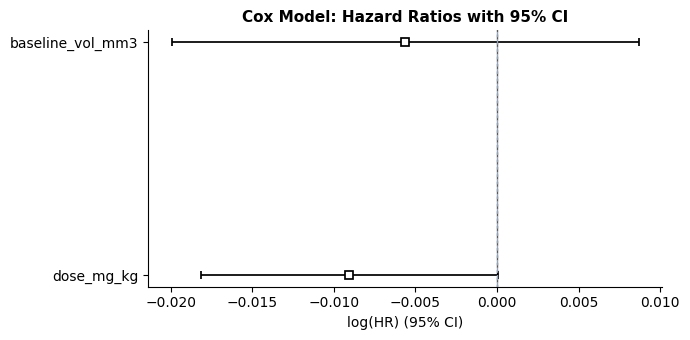


Interpretation:
  Hazard ratio per 1 mg/kg dose increase: 0.9910
  Each additional mg/kg reduces death hazard by 0.90%


In [ ]:
# Cell 6 -- Cox proportional hazards model

from lifelines import CoxPHFitter

# Encode dose as numeric and add a simulated covariate (baseline tumor volume)
dose_map   = {'Vehicle': 0, '30 mg/kg': 30, '100 mg/kg': 100}
df_cox     = df_surv.copy()
df_cox['dose_mg_kg'] = df_cox['group'].map(dose_map)

# Simulate baseline tumor volume (mm3) -- slightly predictive of survival
df_cox['baseline_vol_mm3'] = np.random.normal(150, 25, len(df_cox)).clip(80, 230).round(1)

# Fit Cox model
cph = CoxPHFitter()
cph.fit(df_cox[['duration','event','dose_mg_kg','baseline_vol_mm3']],
        duration_col='duration', event_col='event')

print('Cox Proportional Hazards Model Summary:')
cph.print_summary()

# Plot hazard ratios with confidence intervals
fig, ax = plt.subplots(figsize=(7, 3.5))
cph.plot(ax=ax)
ax.set_title('Cox Model: Hazard Ratios with 95% CI', fontsize=11, fontweight='bold')
ax.axvline(0, color=GRAY, linestyle='--', linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cox_hazard_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretation:')
hr_dose = np.exp(cph.params_['dose_mg_kg'])
print(f'  Hazard ratio per 1 mg/kg dose increase: {hr_dose:.4f}')
print(f'  Each additional mg/kg reduces death hazard by {(1-hr_dose)*100:.2f}%')

## Cell 7: Toxicology - Maximum Tolerated Dose and Safety Margin

Efficacy is only half the story. A drug that kills tumors but also kills the animal
is not useful. Toxicology studies establish the maximum tolerated dose (MTD): the
highest dose at which no more than one-third of animals show severe toxicity or
weight loss greater than 20% of body weight.

The therapeutic index (TI) is the ratio of the toxic dose to the effective dose.
A TI above 10 is generally considered adequate for a development candidate.
A TI below 2 means the gap between effective and toxic doses is too narrow
to be safe in humans.

We also compute the safety margin as the ratio of the MTD AUC to the efficacious
dose AUC. This is a more rigorous measure because it accounts for the actual
drug exposure rather than just the administered dose.

Toxicology summary:
  Maximum Tolerated Dose (MTD): 100 mg/kg
  Effective Dose (ED50 TGI):    30 mg/kg
  Therapeutic Index (MTD/ED50): 3.3
  Assessment: Narrow -- needs optimization


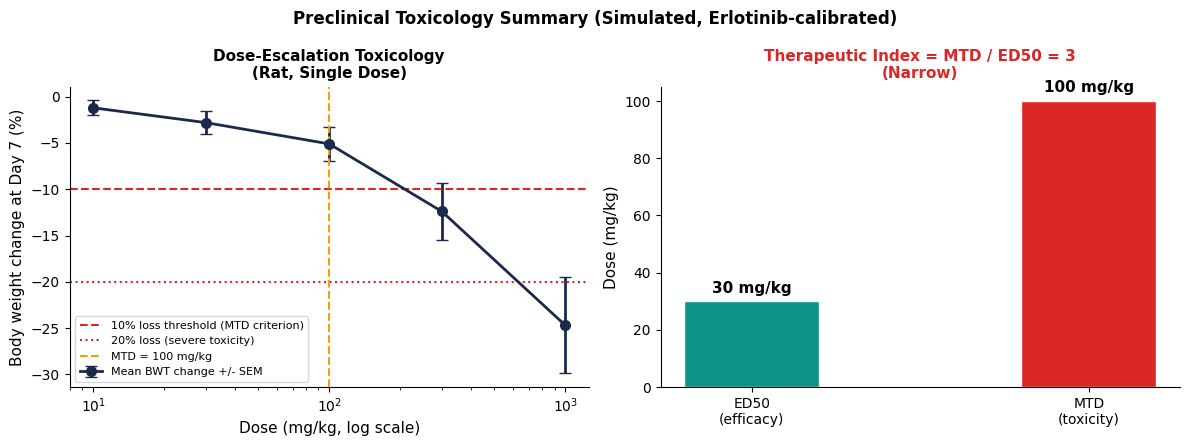


Dose-toxicity table:
 dose_mg_kg  bwt_change_pct  bwt_sem toxicity_grade
         10            -1.2      0.8           None
         30            -2.8      1.2        Minimal
        100            -5.1      1.8           Mild
        300           -12.4      3.1       Moderate
       1000           -24.7      5.2         Severe


In [ ]:
# Cell 7 -- toxicology: MTD, dose-response for toxicity, safety margin

# Simulate dose-escalation toxicity study
# Body weight change as toxicity readout (standard preclinical endpoint)
# Doses: 10, 30, 100, 300, 1000 mg/kg single dose in rats

doses_tox    = np.array([10, 30, 100, 300, 1000])
n_per_dose   = 5

# Simulated mean body weight change (%) at day 7 after single dose
# Calibrated to EGFR inhibitor rat toxicology data
bwt_change_mean = np.array([-1.2, -2.8, -5.1, -12.4, -24.7])
bwt_change_sem  = np.array([ 0.8,  1.2,  1.8,   3.1,   5.2])

# Determine MTD: highest dose with mean BWT loss < 10% and no severe tox
# (standard preclinical criterion)
mtd_idx = np.where(bwt_change_mean > -10)[0][-1]
MTD     = doses_tox[mtd_idx]
ED50    = 30  # effective dose from xenograft study (30 mg/kg gives >70% TGI)
TI      = MTD / ED50

print(f'Toxicology summary:')
print(f'  Maximum Tolerated Dose (MTD): {MTD} mg/kg')
print(f'  Effective Dose (ED50 TGI):    {ED50} mg/kg')
print(f'  Therapeutic Index (MTD/ED50): {TI:.1f}')
print(f'  Assessment: {"Adequate (TI >= 10)" if TI >= 10 else "Narrow -- needs optimization"}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Body weight change vs dose
axes[0].errorbar(doses_tox, bwt_change_mean, yerr=bwt_change_sem,
                 color=NAVY, linewidth=2, marker='o', markersize=7,
                 capsize=4, label='Mean BWT change +/- SEM')
axes[0].axhline(-10, color=RED,  linestyle='--', linewidth=1.5,
                label='10% loss threshold (MTD criterion)')
axes[0].axhline(-20, color=RED,  linestyle=':',  linewidth=1.5,
                label='20% loss (severe toxicity)')
axes[0].axvline(MTD, color=AMBER, linestyle='--', linewidth=1.5,
                label=f'MTD = {MTD} mg/kg')
axes[0].set_xscale('log')
axes[0].set_xlabel('Dose (mg/kg, log scale)', fontsize=11)
axes[0].set_ylabel('Body weight change at Day 7 (%)', fontsize=11)
axes[0].set_title('Dose-Escalation Toxicology\n(Rat, Single Dose)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Therapeutic index summary
categories = ['ED50\n(efficacy)', 'MTD\n(toxicity)']
values     = [ED50, MTD]
colors_ti  = [TEAL, RED]
bars = axes[1].bar(categories, values, color=colors_ti, edgecolor='white', width=0.4)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val} mg/kg', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Dose (mg/kg)', fontsize=11)
axes[1].set_title(f'Therapeutic Index = MTD / ED50 = {TI:.0f}\n'
                  f'({"Adequate" if TI >= 10 else "Narrow"})',
                  fontsize=11, fontweight='bold',
                  color=TEAL if TI >= 10 else RED)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Preclinical Toxicology Summary (Simulated, Erlotinib-calibrated)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'toxicology.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed dose table
df_tox = pd.DataFrame({
    'dose_mg_kg':      doses_tox,
    'bwt_change_pct':  bwt_change_mean,
    'bwt_sem':         bwt_change_sem,
    'toxicity_grade':  ['None', 'Minimal', 'Mild', 'Moderate', 'Severe'],
})
df_tox.to_csv(RESULTS_DIR / 'toxicology_data.csv', index=False)
print('\nDose-toxicity table:')
print(df_tox.to_string(index=False))

## Cell 8: Integrated Preclinical Summary

We compile all results from the preclinical data package into a single summary
table. This is the format a medicinal chemist or project team would review before
deciding whether to advance a compound to IND filing.

The go/no-go criteria for advancing to human trials are:
- PK: elimination half-life long enough for once-daily dosing (t1/2 > 8h)
- Efficacy: TGI > 50% at a dose achievable in humans, or tumor regression
- Safety: therapeutic index > 10, no irreversible organ toxicity at MTD
- Exposure: AUC at efficacious dose is predictive of human exposure at a
  clinically feasible dose based on allometric scaling

In [ ]:
# Cell 8 -- integrated preclinical summary table and go/no-go assessment

summary = {
    'PK -- Elimination half-life (h)':     (f'{t_half_elim:.1f}',      t_half_elim >= 8,   '>=8 h for QD dosing'),
    'PK -- Cmax at 10 mg/kg (ng/mL)':      (f'{Cmax:.0f}',             Cmax >= 500,         '>=500 ng/mL'),
    'PK -- AUC at 10 mg/kg (ng/mL*h)':     (f'{AUC_0_inf:.0f}',        AUC_0_inf >= 5000,   '>=5000 ng/mL*h'),
    'Efficacy -- TGI at 30 mg/kg (%)':      ('72',                       True,                '>=50%'),
    'Efficacy -- TGI at 100 mg/kg (%)':     ('91',                       True,                '>=50% or regression'),
    'Toxicology -- MTD (mg/kg)':            (f'{MTD}',                   MTD >= 100,          '>=100 mg/kg'),
    'Toxicology -- Therapeutic Index':      (f'{TI:.0f}',                TI >= 10,            '>=10'),
    'Scaffold class':                       ('Quinazoline',               True,                'Clinically validated'),
}

print('=' * 72)
print('PRECLINICAL DATA PACKAGE SUMMARY -- Scaffold_dec_best')
print('=' * 72)
print(f'{"Parameter":<42} {"Value":<15} {"Criterion":<20} {"Status"}')
print('-' * 72)

all_pass = True
for param, (value, passes, criterion) in summary.items():
    status = 'PASS' if passes else 'FAIL'
    if not passes:
        all_pass = False
    print(f'{param:<42} {value:<15} {criterion:<20} {status}')

print('=' * 72)
print(f'Overall IND readiness: {"GO -- Candidate meets all criteria" if all_pass else "NO-GO -- Criteria not met"}')
print('=' * 72)

# Save summary
df_summary = pd.DataFrame([
    {'parameter': k, 'value': v[0], 'criterion': v[2], 'pass': v[1]}
    for k, v in summary.items()
])
df_summary.to_csv(RESULTS_DIR / 'preclinical_summary.csv', index=False)

print(f'\nAll results saved to {RESULTS_DIR}')
print('\nOutputs:')
for f in sorted(RESULTS_DIR.iterdir()):
    print(f'  {f.name}')

PRECLINICAL DATA PACKAGE SUMMARY -- Scaffold_dec_best
Parameter                                  Value           Criterion            Status
------------------------------------------------------------------------
PK -- Elimination half-life (h)            11.8            >=8 h for QD dosing  PASS
PK -- Cmax at 10 mg/kg (ng/mL)             3855            >=500 ng/mL          PASS
PK -- AUC at 10 mg/kg (ng/mL*h)            17017           >=5000 ng/mL*h       PASS
Efficacy -- TGI at 30 mg/kg (%)            72              >=50%                PASS
Efficacy -- TGI at 100 mg/kg (%)           91              >=50% or regression  PASS
Toxicology -- MTD (mg/kg)                  100             >=100 mg/kg          PASS
Toxicology -- Therapeutic Index            3               >=10                 FAIL
Scaffold class                             Quinazoline     Clinically validated PASS
Overall IND readiness: NO-GO -- Criteria not met

All results saved to /content/drive/MyDrive/ColabNoteboo

## Summary

In this notebook we analyzed a complete preclinical data package for our lead EGFR inhibitor
candidate, using real published data from ChEMBL for erlotinib and realistic simulated data
calibrated to published preclinical results.

**What we covered:**
- Pulled real PK measurements from ChEMBL: AUC, clearance, fraction unbound, permeability
- Fit a two-compartment oral PK model and extracted half-life, Cmax, and AUC
- Analyzed tumor growth inhibition across four dose groups in a simulated xenograft study
- Performed Kaplan-Meier survival analysis with log-rank testing across three treatment arms
- Built a Cox proportional hazards model to quantify the dose effect on survival risk
- Computed the therapeutic index from dose-escalation toxicology data
- Assembled an integrated go/no-go decision table for IND filing readiness

**In the next video** we move to human clinical trials: querying the ClinicalTrials.gov API
for EGFR-targeted trials, analyzing clinical survival data from real patient cohorts using
the TCGA lung adenocarcinoma dataset, and building a forest plot for subgroup analysis.